# Regime-Stratified Sensitivity Analysis — Level 5 (no surface kinetics)

Sensitivity of the **L5** model (defective oxide L3 + defective metal microstructure L4)
**conditioned on the rate-limiting regime**, run **isothermally** at several temperatures.
This is the no-surface-kinetics counterpart of `sensitivity_regime_L5L6.ipynb`.

## Regimes — oxide / metal / defect

Without a surface step there are only two series resistances, so the third competitor is the
**parallel** one: flux that bypasses the intact oxide through pinholes, cracks and
grain-boundary paths.

```
frac_oxide  = (P_up - P_int)/P_up * (1 - frac_defect)     series, from the solved
frac_metal  =  P_int/P_up        * (1 - frac_defect)      interface pressure (exact)
frac_defect =  J_defect / J_total                         parallel bypass
regime      = argmax of the three
```

The series split is read off the solved interface pressure rather than from
`calculate_metal_resistance`, whose Taylor form assumes small dP while these sweeps run
`P_downstream = 0`. On a 300-draw probe the two definitions agreed on 99.0% of rows
(corr 0.987).

## Why isothermal

`temperature` enters `D`, `K_s`, `D_ox` and `K_ox` exponentially over 573-1273 K, so with it
varying it monopolises the variance of log10(flux). A dummy-parameter test on varying-T
clusters found `temperature` at delta ~0.50 and **every other parameter at or below the noise
floor (~0.09)** — a table of noise that reads like a ranking. Sampling harder does not help:
the floor is flat in n (0.085 at n=400, 0.092 at n=1500) because delta's bias for an
irrelevant input does not shrink with sample size. Pinning the temperature is what lets the
remaining parameters compete.

Every result table now carries a **`floor`** column (max delta over 3 dummy inputs the model
never saw) and **`delta_over_floor`**. Treat any parameter at or below 1.0x as unresolved.

## Targeting is not optional

Over the default ranges the model is ~98% metal-limited with `max frac_defect = 0.415` — one
regime, nothing to stratify. The presets create the study.

> **Assumption to state in any write-up:** the `defect` preset allows a total defect area up
> to ~0.9 — a heavily degraded coating, a wider claim than the <=0.3 the default ranges imply.

> **`permeability` is bulk-only here** — a harmonic mean of the oxide and metal permeabilities
> that ignores the defect paths entirely, so it will look insensitive to the very parameters
> defining the `defect` regime. Read `flux` and `PRF` for that cluster.

Run with the **`mace_env`** kernel (SALib pinned to 1.5.0).

In [1]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import calculations.sensitivity as sens
importlib.reload(sens)
from calculations.config.model_config import (
    SUGGESTED_RANGES_LEVEL5, REGIME_PRESETS_L5, DEFAULT_SWEEP_TEMPERATURES,
    MEASURED_YIELDS_L5_BY_T
)
from calculations.sensitivity import (
    REGIME_LABELS_L5, REGIME_SA_METRICS_L5, LOG_METRICS_L5, SCAN_OUTPUT_FIELDS_L5,
    SCAN_LABEL_FIELDS_L5, presets_without, level5_model_wrapper,
    run_targeted_regime_scans, load_regime_scans, plot_regime_exploration,
    givendata_sensitivity_by_regime, summarize_givendata, plot_givendata_results,
    regime_comparison_matrix, plot_regime_comparison_heatmap, plot_regime_geometry
)

# temperature is PINNED, not sampled -> it leaves the SA input set entirely
PRESETS = presets_without(REGIME_PRESETS_L5, 'temperature')
PARAMS  = [p for p in SUGGESTED_RANGES_LEVEL5 if p != 'temperature']
print(f"{len(PARAMS)} sampled parameters (temperature pinned); regimes: {REGIME_LABELS_L5}")

27 sampled parameters (temperature pinned); regimes: ('oxide', 'metal', 'defect')


In [3]:
# === Run configuration ========================================================
SEED         = 42
TEMPERATURES = list(DEFAULT_SWEEP_TEMPERATURES)      # 773 / 1073 / 1273 K
TARGET_N     = 1500                                  # in-regime points per cluster
METRICS      = REGIME_SA_METRICS_L5                  # ['flux', 'permeability', 'PRF']
TOP_K        = 8

# draws = target / measured yield, per temperature — yields shift with T, so a single
# dict would leave the worst-yielding cluster far smaller and reintroduce the very
# noise-floor imbalance the isothermal design is meant to remove.
N_BY_T = {T: {r: int(round(TARGET_N / MEASURED_YIELDS_L5_BY_T[T][r]))
              for r in REGIME_LABELS_L5} for T in TEMPERATURES}

RESULTS_DIR     = "sa_results_L5"
FORCE_RECOMPUTE = False
os.makedirs(RESULTS_DIR, exist_ok=True)

for T in TEMPERATURES:
    print(f"  T={T:.0f}K  draws={N_BY_T[T]}  total={sum(N_BY_T[T].values())}")
print("grand total:", sum(sum(v.values()) for v in N_BY_T.values()), "model evaluations")

  T=773K  draws={'oxide': 1638, 'metal': 1512, 'defect': 1638}  total=4788
  T=1073K  draws={'oxide': 2143, 'metal': 1518, 'defect': 1829}  total=5490
  T=1273K  draws={'oxide': 2534, 'metal': 1543, 'defect': 1875}  total=5952
grand total: 16230 model evaluations


## Phase 1 — Targeted per-regime scans, one set per temperature

Cached to `sa_results_L5/scans/T<K>/scan_<regime>.csv`. The cache is only reused when every
file holds exactly the draw count currently requested — existence alone would silently serve
a previous configuration.

In [4]:
def cache_is_valid(paths, n_expected):
    """Reusable only if every scan exists AND matches the requested draw count."""
    for r, p in paths.items():
        if not os.path.exists(p):
            return False, f"{os.path.basename(p)} missing"
        n_have = len(pd.read_csv(p, usecols=[0]))
        if n_have != n_expected[r]:
            return False, (f"{os.path.basename(p)} holds {n_have} draws but config "
                           f"asks for {n_expected[r]}")
    return True, "every scan matches the requested draw counts"


clusters_T, scans_T, yields_T = {}, {}, {}

for T in TEMPERATURES:
    scan_dir = os.path.join(RESULTS_DIR, "scans", f"T{int(T)}")
    os.makedirs(scan_dir, exist_ok=True)
    paths = {r: os.path.join(scan_dir, f"scan_{r}.csv") for r in REGIME_LABELS_L5}
    reusable, why = cache_is_valid(paths, N_BY_T[T])

    print(f"\n{'='*70}\nT = {T:.0f} K\n{'='*70}")
    if (not FORCE_RECOMPUTE) and reusable:
        print(f"  loading cached scans ({why})")
        cl, sc, _ = load_regime_scans(scan_dir, regimes=REGIME_LABELS_L5)
        yl = {r: len(cl[r]) / len(sc[r]) for r in cl}
    else:
        print("  recomputing —", "FORCE_RECOMPUTE is set" if FORCE_RECOMPUTE else why)
        cl, sc, _, yl = run_targeted_regime_scans(
            N_per_regime=N_BY_T[T], regimes=REGIME_LABELS_L5,
            presets=PRESETS, wrapper=level5_model_wrapper,
            output_fields=SCAN_OUTPUT_FIELDS_L5, label_fields=SCAN_LABEL_FIELDS_L5,
            fixed_params={'temperature': T},
            seed=SEED, save_dir=scan_dir, verbose=False)
    clusters_T[T], scans_T[T], yields_T[T] = cl, sc, yl
    print("  clusters:", {r: len(cl[r]) for r in REGIME_LABELS_L5})
    print("  yields:  ", {r: f"{yl[r]*100:.1f}%" for r in REGIME_LABELS_L5})

master = pd.concat(
    [cl.assign(temperature_K=T) for T, c in clusters_T.items() for cl in [pd.concat(c.values())]],
    ignore_index=True)
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print(f"\nmaster_clusters.csv: {len(master)} rows")


T = 773 K
  recomputing — scan_oxide.csv missing
  saved scan -> sa_results_L5/scans/T773/scan_oxide.csv
  saved scan -> sa_results_L5/scans/T773/scan_metal.csv
  saved scan -> sa_results_L5/scans/T773/scan_defect.csv
  clusters: {'oxide': 1499, 'metal': 1494, 'defect': 1489}
  yields:   {'oxide': '91.5%', 'metal': '98.8%', 'defect': '90.9%'}

T = 1073 K
  recomputing — scan_oxide.csv missing
  saved scan -> sa_results_L5/scans/T1073/scan_oxide.csv
  saved scan -> sa_results_L5/scans/T1073/scan_metal.csv
  saved scan -> sa_results_L5/scans/T1073/scan_defect.csv
  clusters: {'oxide': 1497, 'metal': 1491, 'defect': 1518}
  yields:   {'oxide': '69.9%', 'metal': '98.2%', 'defect': '83.0%'}

T = 1273 K
  recomputing — scan_oxide.csv missing
  saved scan -> sa_results_L5/scans/T1273/scan_oxide.csv
  saved scan -> sa_results_L5/scans/T1273/scan_metal.csv
  saved scan -> sa_results_L5/scans/T1273/scan_defect.csv
  clusters: {'oxide': 1544, 'metal': 1494, 'defect': 1477}
  yields:   {'oxide': 

In [5]:
# Median outputs by temperature and regime — the physical sanity check
print(master.groupby(['temperature_K', 'regime'])[METRICS].median().to_string())

                              flux  permeability        PRF
temperature_K regime                                       
773.0         defect  4.919885e-07  3.452842e-19   1.563128
              metal   6.557235e-07  3.031465e-16   1.001055
              oxide   2.942691e-07  3.374596e-19  30.946555
1073.0        defect  1.567517e-04  2.308285e-16   1.240518
              metal   2.273777e-04  3.480989e-13   1.000211
              oxide   9.648781e-05  1.063725e-16  27.487573
1273.0        defect  1.536753e-03  2.917574e-15   1.187585
              metal   2.218404e-03  7.652645e-12   1.000102
              oxide   6.806516e-04  7.872545e-16  33.477829



===== T = 773 K =====


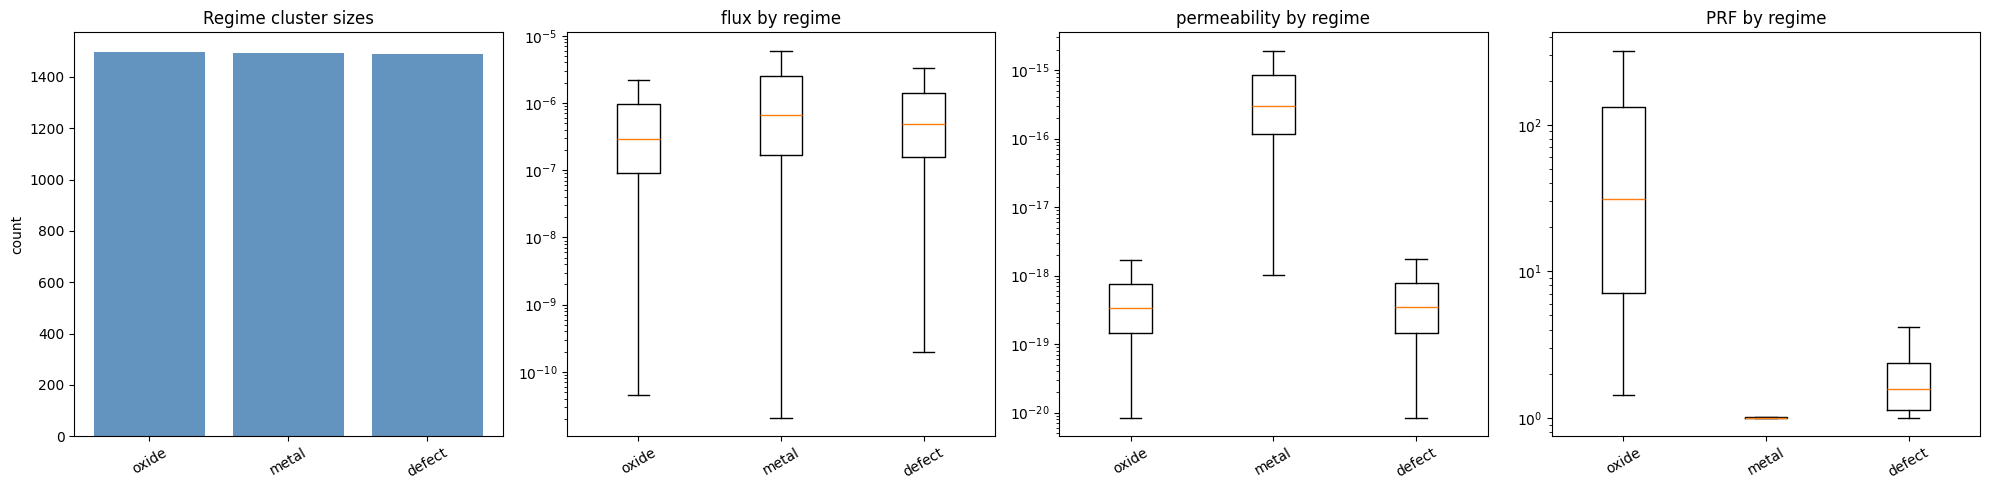


  regime (argmax)  ×  regime_hierarchy (solver):
regime_hierarchy  metal_limited/lattice_limited  metal_limited/traps_defect_limited  oxide_limited/defect_limited  oxide_limited/regime_intact_oxide  transition
regime                                                                                                                                                          
defect                                        0                                 208                           613                                  0         669
metal                                         4                                1606                             0                                  0         162
oxide                                         0                                   0                             0                               1229         297

===== T = 1073 K =====


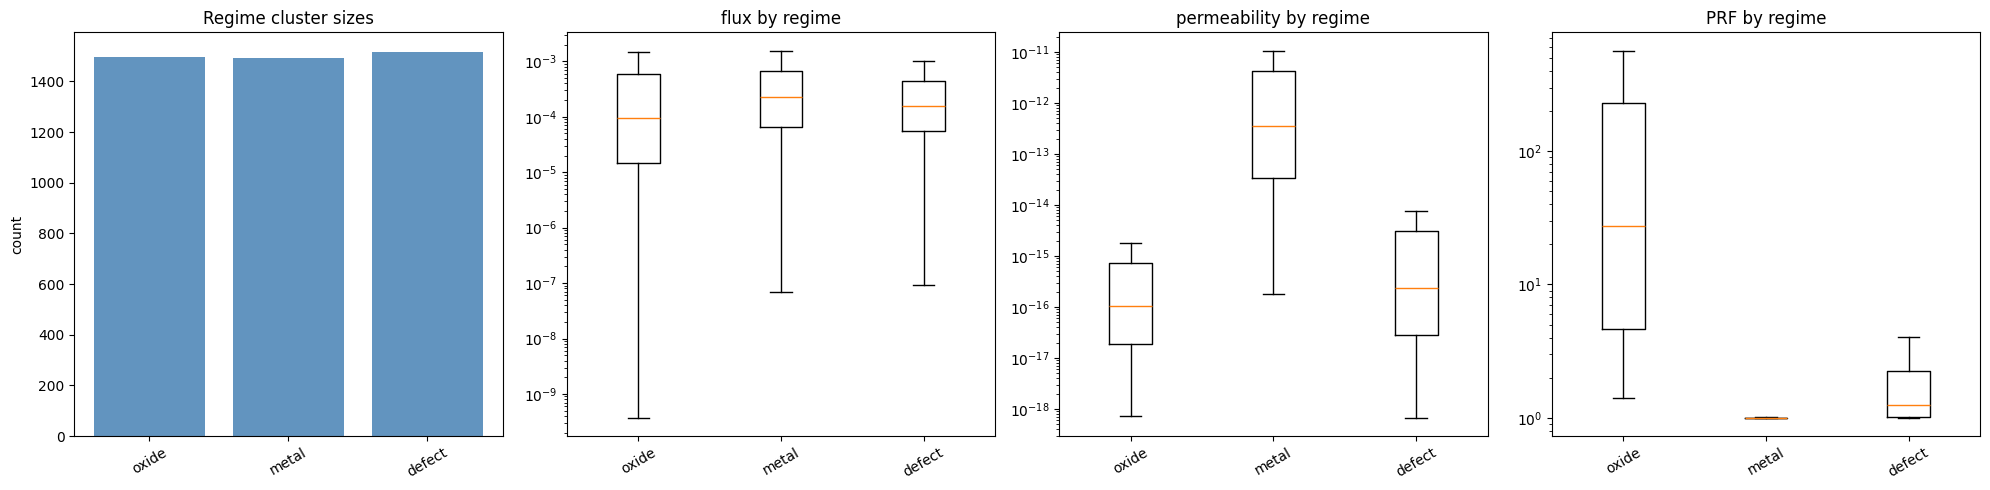


  regime (argmax)  ×  regime_hierarchy (solver):
regime_hierarchy  metal_limited/lattice_limited  metal_limited/traps_defect_limited  oxide_limited/defect_limited  oxide_limited/regime_intact_oxide  transition
regime                                                                                                                                                          
defect                                       20                                 450                           521                                  0         531
metal                                       106                                2012                             0                                  0         326
oxide                                         0                                   0                             0                               1131         393

===== T = 1273 K =====


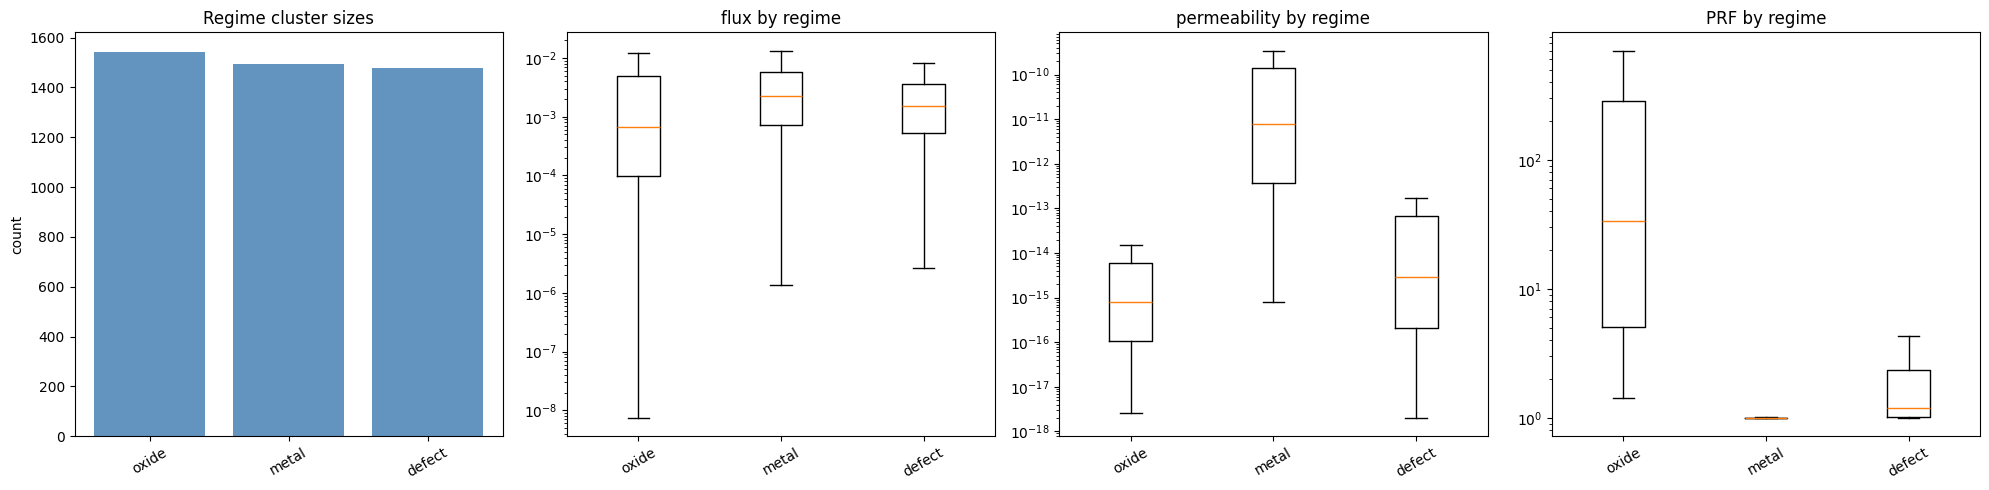


  regime (argmax)  ×  regime_hierarchy (solver):
regime_hierarchy  metal_limited/lattice_limited  metal_limited/traps_defect_limited  oxide_limited/defect_limited  oxide_limited/regime_intact_oxide  transition
regime                                                                                                                                                          
defect                                       87                                 461                           501                                  0         441
metal                                       344                                2175                             0                                  0         358
oxide                                         0                                   0                             0                               1175         410


In [6]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    plot_regime_exploration(clusters_T[T], output_metrics=tuple(METRICS),
                            scan_df=pd.concat(scans_T[T].values(), ignore_index=True),
                            cross_col='regime_hierarchy')

## Phase 2 — Route B: given-data PAWN + delta, per temperature

Zero extra model evaluations. Each `(regime, metric)` entry carries the dummy-parameter
noise `floor`; `delta_over_floor <= 1` means the parameter is **not resolved**.

In [7]:
gd_T, tidy_T = {}, {}
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    gd_T[T] = givendata_sensitivity_by_regime(
        clusters_T[T], PARAMS, output_metrics=METRICS, methods=('pawn', 'delta'),
        seed=SEED, log_metrics=LOG_METRICS_L5, n_dummy=3, verbose=True)
    tidy_T[T] = summarize_givendata(gd_T[T], PARAMS).assign(temperature_K=T)

tidy = pd.concat(tidy_T.values(), ignore_index=True)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)
print(f"\nrouteB_givendata.csv: {len(tidy)} rows")


===== T = 773 K =====
  [oxide/flux] n= 1499  floor=0.101  top-δ: H_sol_ox (0.242)
  [oxide/permeability] n= 1499  floor=0.078  top-δ: H_sol_ox (0.382)
  [oxide/PRF] n= 1499  floor=0.078  top-δ: H_sol_ox (0.168)
  [metal/flux] n= 1494  floor=0.102  top-δ: H_s (0.199)
  [metal/permeability] n= 1494  floor=0.061  top-δ: H_sol_ox (0.341)
  [metal/PRF] n= 1494  floor=0.098  top-δ: H_sol_ox (0.181)
  [defect/flux] n= 1489  floor=0.076  top-δ: P_upstream (0.145)
  [defect/permeability] n= 1489  floor=0.081  top-δ: H_sol_ox (0.395)
  [defect/PRF] n= 1489  floor=0.071  top-δ: H_sol_ox (0.125)

===== T = 1073 K =====
  [oxide/flux] n= 1497  floor=0.079  top-δ: H_sol_ox (0.391)
  [oxide/permeability] n= 1497  floor=0.066  top-δ: H_sol_ox (0.598)
  [oxide/PRF] n= 1497  floor=0.064  top-δ: H_sol_ox (0.312)
  [metal/flux] n= 1491  floor=0.090  top-δ: K_s_ref (0.177)
  [metal/permeability] n= 1491  floor=0.097  top-δ: H_sol_ox (0.586)
  [metal/PRF] n= 1491  floor=0.126  top-δ: H_sol_ox (1.789)
  [d

In [8]:
# Drivers of log10(flux) — EVERY parameter, no threshold.
# `floor` is the best delta scored by a dummy input the model never saw, so
# delta_over_floor <= 1.0 means "indistinguishable from noise". Showing only the
# rows above 1.0 creates an artificial cliff (0.99 hidden, 1.01 shown) and hides
# how wide the noise band is — so nothing is filtered here. Read the margin, not
# the presence of a row.
for T in TEMPERATURES:
    for reg in REGIME_LABELS_L5:
        sub = (tidy[(tidy.metric == 'flux') & (tidy.temperature_K == T)
                    & (tidy.regime == reg)]
               .sort_values('delta_over_floor', ascending=False))
        floor = sub['floor'].iloc[0]
        n_res = int((sub.delta_over_floor > 1.0).sum())
        print(f"  T={T:.0f}K  {reg:7s}  floor={floor:.3f}  "
              f"({n_res}/{len(sub)} above 1.0x)")
        for _, r_ in sub.head(8).iterrows():
            mark = '' if r_.delta_over_floor > 1.0 else '   <- at/below noise'
            print(f"        {r_.parameter:24s} delta={r_.delta:.3f}"
                  f"  ({r_.delta_over_floor:.2f}x){mark}")
    print()

  T=773K  oxide    floor=0.101  (6/27 above 1.0x)
        H_sol_ox                 delta=0.242  (2.40x)
        P_upstream               delta=0.207  (2.05x)
        oxide_thickness          delta=0.149  (1.47x)
        K_ox_ref                 delta=0.135  (1.34x)
        D_ox_ref                 delta=0.129  (1.27x)
        E_D                      delta=0.104  (1.03x)
        H_s                      delta=0.095  (0.94x)   <- at/below noise
        gb_diffusivity_factor    delta=0.095  (0.94x)   <- at/below noise
  T=773K  metal    floor=0.102  (7/27 above 1.0x)
        H_s                      delta=0.199  (1.95x)
        K_s_ref                  delta=0.161  (1.57x)
        trap_vacancy_E_b         delta=0.154  (1.51x)
        D_ref                    delta=0.150  (1.47x)
        trap_vacancy_N_T         delta=0.140  (1.37x)
        metal_thickness          delta=0.115  (1.13x)
        P_upstream               delta=0.106  (1.04x)
        grain_size               delta=0.098  (0.9

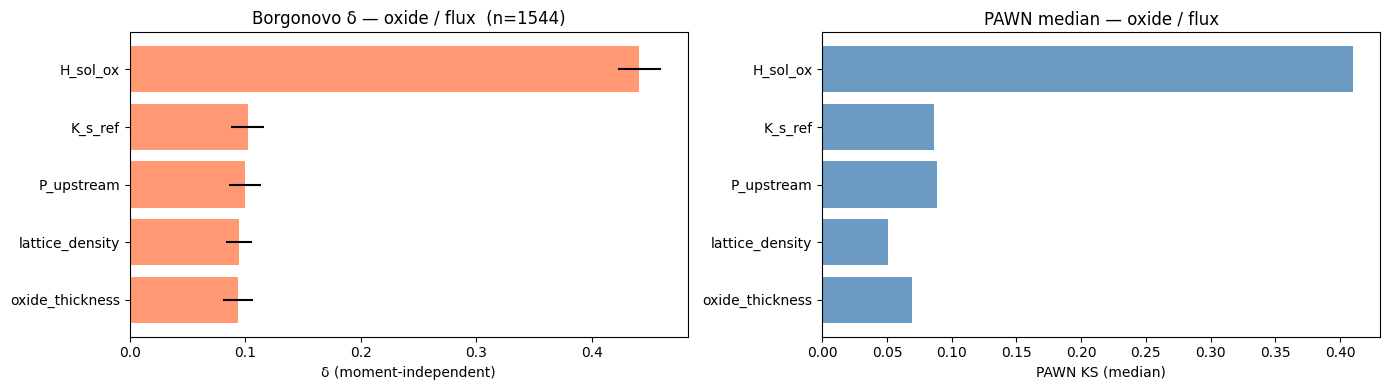

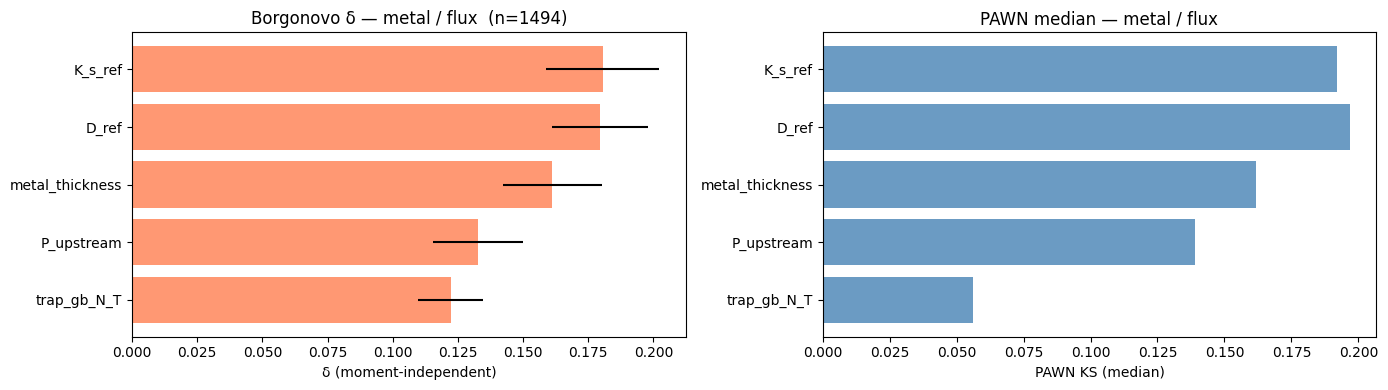

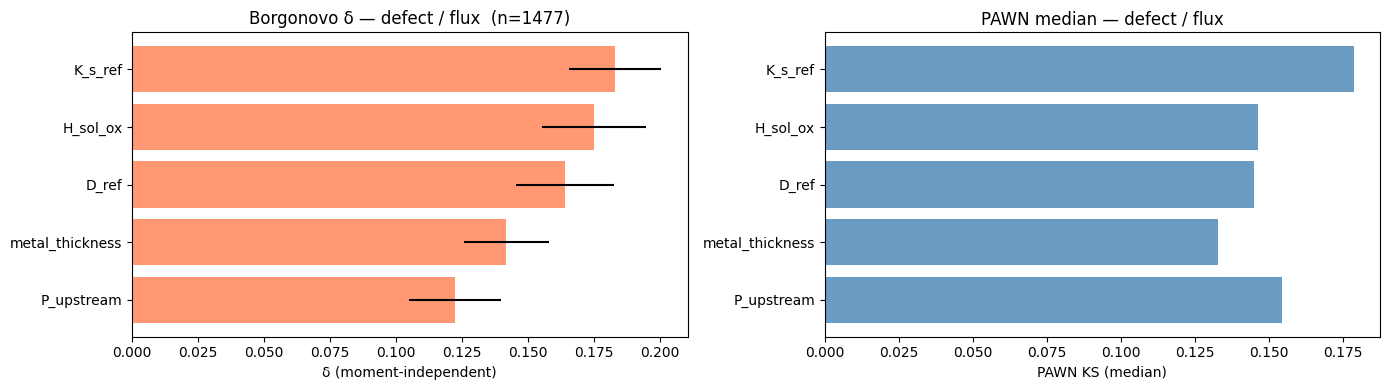

In [14]:
for reg in REGIME_LABELS_L5:
    plot_givendata_results(gd_T[TEMPERATURES[-1]], reg, 'flux', PARAMS, top_n=5)

## Phase 2 (cont.) — regime geometry (highest temperature)

Clusters projected on their two strongest resolved drivers. Dashed boxes are the 10-90
percentile band; overlap is the reminder that regime boundaries are curved, not rectangular.

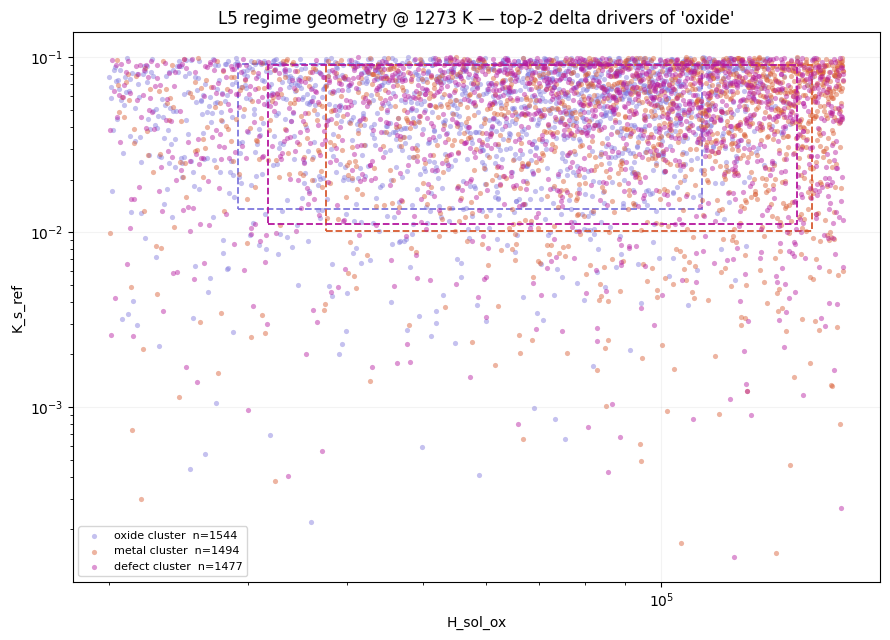

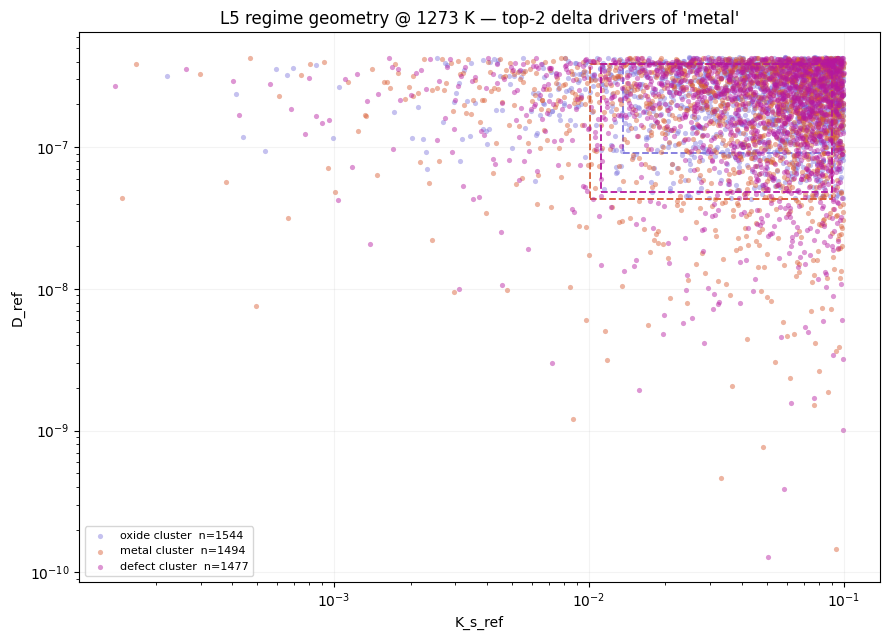

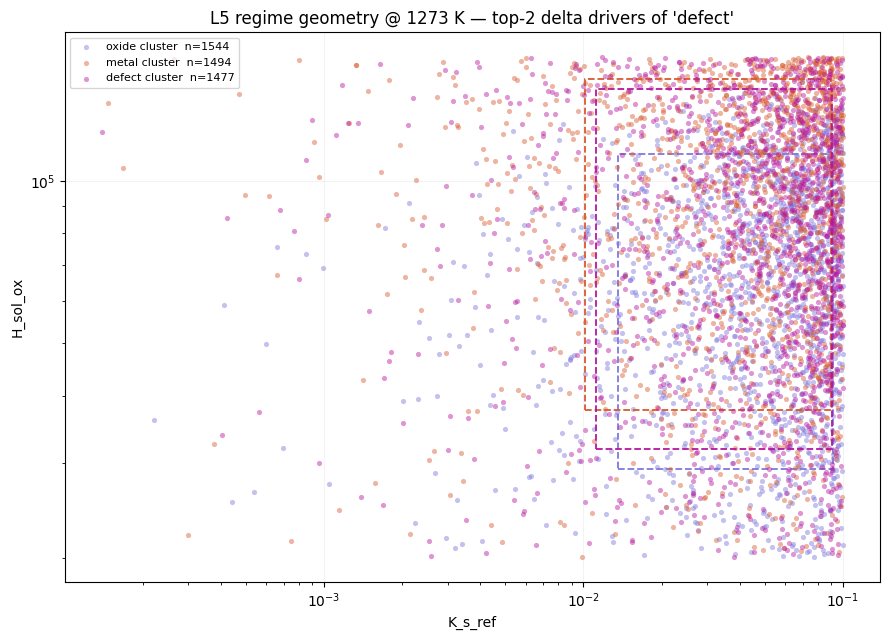

In [10]:
T_show = TEMPERATURES[-1]
def regime_topk(reg, k=TOP_K, metric='flux', T=None):
    """Top-k parameters for one regime at one temperature, ranked by Route-B delta."""
    T = T_show if T is None else T
    sub = tidy[(tidy.temperature_K == T) & (tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

for reg in REGIME_LABELS_L5:
    plot_regime_geometry(clusters_T[T_show], axes=regime_topk(reg)[:2],
                         log_x=True, log_y=True,
                         title=f"L5 regime geometry @ {T_show:.0f} K — top-2 delta drivers of '{reg}'")

## Phase 3 — Cross-regime comparison, per temperature

Columns are column-normalised so each regime spans a full 0-1 scale; the small corner number
is the raw index. Exported `compare_*.csv` files are always raw.


===== T = 773 K — delta, log10(flux) =====


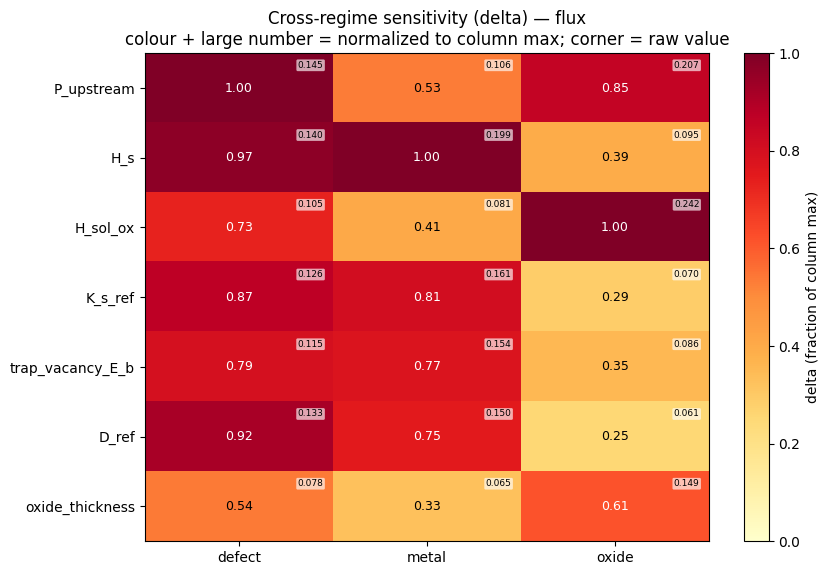


===== T = 1073 K — delta, log10(flux) =====


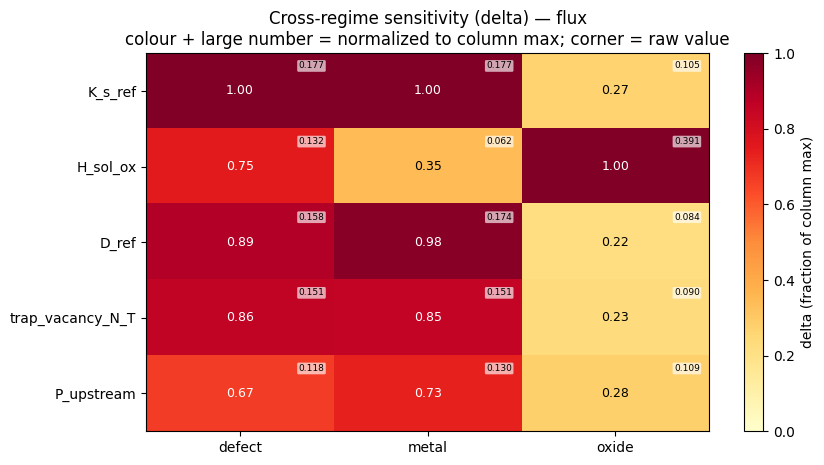


===== T = 1273 K — delta, log10(flux) =====


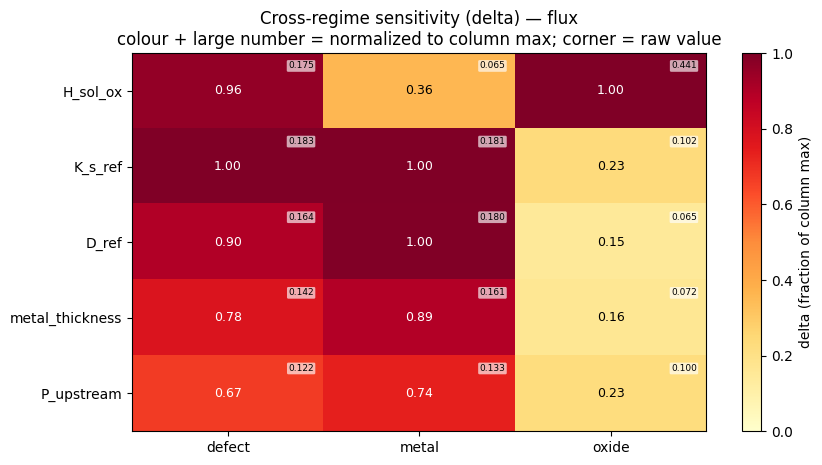

In [17]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K — delta, log10(flux) =====")
    plot_regime_comparison_heatmap(gd_T[T], 'flux', PARAMS, index='delta', top_union=3)
    for idx in ('delta', 'pawn_median'):
        for met in METRICS:
            mat = regime_comparison_matrix(gd_T[T], met, PARAMS, index=idx, top_union=3)
            if not mat.empty:
                mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}_T{int(T)}.csv"))

In [12]:
# How does each parameter's margin over the noise floor move with temperature?
# Unfiltered: every parameter appears at every T, so a value near 1.0 reads as
# "at the noise floor" instead of vanishing into a NaN that looks like missing data.
piv = (tidy[tidy.metric == 'flux']
       .pivot_table(index=['regime', 'parameter'], columns='temperature_K',
                    values='delta_over_floor'))
piv.columns = [f"{c:.0f}K" for c in piv.columns]
piv['best'] = piv.max(axis=1)

print("delta_over_floor for log10(flux) — ALL parameters, no threshold")
print("  1.0 = exactly at the dummy-parameter noise floor; higher = resolved\n")
for reg in REGIME_LABELS_L5:
    fl = (tidy[(tidy.metric == 'flux') & (tidy.regime == reg)]
          .groupby('temperature_K')['floor'].first())
    print(f"[{reg}]  floor: " + "  ".join(f"{T:.0f}K={v:.3f}" for T, v in fl.items()))
    print(piv.loc[reg].sort_values('best', ascending=False).round(2).to_string())
    print()

piv.to_csv(os.path.join(RESULTS_DIR, "delta_over_floor_by_T.csv"))
print("saved delta_over_floor_by_T.csv")

delta_over_floor for log10(flux) — ALL parameters, no threshold
  1.0 = exactly at the dummy-parameter noise floor; higher = resolved

[oxide]  floor: 773K=0.101  1073K=0.079  1273K=0.080
                        773K  1073K  1273K  best
parameter                                       
H_sol_ox                2.40   4.95   5.49  5.49
P_upstream              2.05   1.38   1.24  2.05
oxide_thickness         1.47   0.78   1.16  1.47
K_ox_ref                1.34   1.29   1.08  1.34
K_s_ref                 0.69   1.33   1.27  1.33
D_ox_ref                1.27   1.00   1.13  1.27
lattice_density         0.68   0.88   1.18  1.18
f_gb_defect             0.52   1.15   0.62  1.15
trap_vacancy_N_T        0.67   1.14   1.15  1.15
E_D_ox                  0.42   1.12   0.60  1.12
E_D                     1.03   1.12   0.44  1.12
trap_vacancy_E_b        0.85   1.08   0.86  1.08
D_ref                   0.61   1.07   0.81  1.07
metal_thickness         0.68   1.06   0.90  1.06
grain_size              0.58

In [13]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")

Saved CSV files under /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/incoloy802_cr203/sa_results_L5 :
   compare_delta_PRF_T1073.csv (1 KB)
   compare_delta_PRF_T1273.csv (1 KB)
   compare_delta_PRF_T773.csv (1 KB)
   compare_delta_flux_T1073.csv (1 KB)
   compare_delta_flux_T1273.csv (1 KB)
   compare_delta_flux_T773.csv (1 KB)
   compare_delta_permeability_T1073.csv (1 KB)
   compare_delta_permeability_T1273.csv (1 KB)
   compare_delta_permeability_T773.csv (1 KB)
   compare_pawn_median_PRF_T1073.csv (1 KB)
   compare_pawn_median_PRF_T1273.csv (1 KB)
   compare_pawn_median_PRF_T773.csv (1 KB)
   compare_pawn_median_flux_T1073.csv (1 KB)
   compare_pawn_median_flux_T1273.csv (1 KB)
   compare_pawn_median_flux_T773.csv (1 KB)
   compare_pawn_median_permeability_T1073.csv (1 KB)
   compare_pawn_median_permeability_T1273.csv (1 KB)
   compare_pawn_median_permeability_T773.csv (1 KB)
   delta_over_floor_by_T.csv (7 KB)
   master_clusters.csv (11358 KB)
   route